§5. Working with Excel files

#Working with .xlsx (Microsoft Excel) files in Python is typically done using libraries such as openpyxl, xlrd, pandas, or xlwt, depending on your needs. Here are examples of how to work with .xlsx files using the openpyxl library.

# **Task: Create a Student Performance Report**

# Problem

# The Programming for AI course has the following student results:

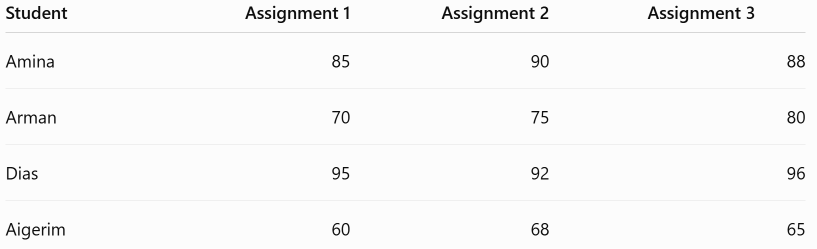

# **Your task is to create an Excel report student_report.xlsx.**

In [ ]:
pip install openpyxl

# Step 1. Create the workbook

In [1]:
import openpyxl

# Create a new workbook
workbook = openpyxl.Workbook()

# Get the active worksheet
sheet = workbook.active

# Rename the worksheet
sheet.title = "Students"

# Save the workbook
workbook.save("student_report.xlsx")

print("Excel file created.")

Excel file created.


# Step 2. Create the table

In [14]:
# Open the file .xlsx
workbook = openpyxl.load_workbook('student_report.xlsx')
# Select the worksheet
sheet = workbook["Students"]

In [15]:
sheet.append(["No.", "Student", "Assignment 1",
              "Assignment 2", "Assignment 3"])

students = [
    ["Amina", 85, 90, 88],
    ["Arman", 70, 75, 80],
    ["Dias", 95, 92, 96],
    ["Aigerim", 60, 68, 65]
]

for i, student in enumerate(students, start=1):
    sheet.append([i] + student)

# Save the book to a file
workbook.save("student_report.xlsx")

print("Student data saved.")


Student data saved.


# Step 3. Open and read the Excel file
# Open the existing Excel file and display all student records.

In [16]:
import openpyxl

workbook = openpyxl.load_workbook("student_report.xlsx")

sheet = workbook["Students"]

for row in sheet.iter_rows(values_only=True):
    print(row)

('No.', 'Student', 'Assignment 1', 'Assignment 2', 'Assignment 3')
(1, 'Amina', 85, 90, 88)
(2, 'Arman', 70, 75, 80)
(3, 'Dias', 95, 92, 96)
(4, 'Aigerim', 60, 68, 65)


# values_only=True - means that we get cell values ​​rather than Cell objects

# Step 4. Read specific cells

In [17]:
# Read specific cells
print(sheet["B2"].value)
print(sheet["C2"].value)

# Read using row and column numbers
print(sheet.cell(row=2, column=2).value)

Amina
85
Amina


# Step 5. Modify existing data
# Arman completed a correction. Change his Assignment 2 score from 75 to 82.

In [18]:
for row in range(2, sheet.max_row + 1):

    name = sheet[f"B{row}"].value

    if name == "Arman":
        sheet[f"D{row}"] = 82

workbook.save("student_report.xlsx")

print("Arman's score updated.")

Arman's score updated.


# Step 6. Add calculated columns: Average, Result

# Calculate the average score for each student. A student passes if the average score is at least 70.

In [19]:
sheet["F1"] = "Average"
sheet["G1"] = "Result"

for row in range(2, sheet.max_row + 1):

    scores = [
        sheet[f"C{row}"].value,
        sheet[f"D{row}"].value,
        sheet[f"E{row}"].value
    ]

    average = sum(scores) / len(scores)

    sheet[f"F{row}"] = round(average, 2)

    if average >= 70:
        sheet[f"G{row}"] = "Pass"
    else:
        sheet[f"G{row}"] = "Fail"

workbook.save("student_report.xlsx")

print("Average scores and results calculated.")

Average scores and results calculated.


# Step 7. Add a new student
# A new student joined the course. Add the student to the end of the table.

In [20]:
name = "Miras"
assignment1 = 78
assignment2 = 85
assignment3 = 80

average = (assignment1 + assignment2 + assignment3) / 3

if average >= 70:
    result = "Pass"
else:
    result = "Fail"

number = sheet.max_row

sheet.append([
    number,
    name,
    assignment1,
    assignment2,
    assignment3,
    round(average, 2),
    result
])

workbook.save("student_report.xlsx")

print("New student added.")

New student added.


# Step 8. Create a Summary worksheet
# Create a new worksheet called Summary and calculate general course statistics.

In [21]:
students_sheet = workbook["Students"]

# Remove old Summary sheet if it already exists
if "Summary" in workbook.sheetnames:
    del workbook["Summary"]

# Create a new worksheet
summary_sheet = workbook.create_sheet("Summary")

averages = []
passed = 0
failed = 0

for row in range(2, students_sheet.max_row + 1):
    average = students_sheet[f"F{row}"].value
    result = students_sheet[f"G{row}"].value

    averages.append(average)

    if result == "Pass":
        passed += 1
    else:
        failed += 1

# Write summary
summary_sheet.append(["Metric", "Value"])
summary_sheet.append(["Number of students", len(averages)])
summary_sheet.append(["Course average", round(sum(averages) / len(averages), 2)])
summary_sheet.append(["Highest average", max(averages)])
summary_sheet.append(["Lowest average", min(averages)])
summary_sheet.append(["Passed", passed])
summary_sheet.append(["Failed", failed])

workbook.save("student_report.xlsx")

print("Summary worksheet created.")

Summary worksheet created.


# Step 9. Format the Excel report

In [22]:
import openpyxl

from openpyxl.styles import Font, Alignment
from openpyxl.utils import get_column_letter

workbook = openpyxl.load_workbook("student_report.xlsx")

for sheet in workbook.worksheets:

    # Format header
    for cell in sheet[1]:
        cell.font = Font(bold=True)
        cell.alignment = Alignment(horizontal="center")

    # Adjust column widths
    for col in range(1, sheet.max_column + 1):

        letter = get_column_letter(col)
        max_len = 0

        for row in range(1, sheet.max_row + 1):

            value = sheet.cell(row, col).value

            if value is not None:
                max_len = max(max_len, len(str(value)))

        sheet.column_dimensions[letter].width = max(
            10,
            min(30, max_len + 2)
        )

workbook.save("student_report.xlsx")

print("Report formatted.")

Report formatted.


In [23]:
# Closing the file
workbook.close()

# Create file → Write → Save → Open → Read → Access cells → Modify → Calculate → Add rows → Create worksheet → Format → Save.